# 04-image-text-alignment: Notebook này dùng để EDA mối quan hệ giữa ảnh và report (image–text alignment).

In [5]:
import os
import json
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image

In [6]:
data_path = r"D:\HocTap\NCKH_ThayDoNhuTai\A3Net\data\iu_xray\annotation.json"
image_root = r"D:\HocTap\NCKH_ThayDoNhuTai\A3Net\data\iu_xray\images"

with open(data_path, "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['train', 'val', 'test'])


In [7]:
records = []

for split in ["train","val","test"]:
    
    for item in data[split]:
        
        records.append({
            "id": item["id"],
            "report": item["report"],
            "image_paths": item["image_path"],
            "num_images": len(item["image_path"]),
            "split": split
        })

df = pd.DataFrame(records)

df.head()

,id,report,image_paths,num_images,split
0,CXR2384_IM-0942,The heart size and pulmonary vascularity appea...,"[CXR2384_IM-0942/0.png, CXR2384_IM-0942/1.png]",2,train
1,CXR2926_IM-1328,Cardiac and mediastinal contours are within no...,"[CXR2926_IM-1328/0.png, CXR2926_IM-1328/1.png]",2,train
2,CXR1451_IM-0291,Left lower lobe calcified granuloma. Heart siz...,"[CXR1451_IM-0291/0.png, CXR1451_IM-0291/1.png]",2,train
3,CXR2887_IM-1289,The cardiomediastinal silhouette is normal in ...,"[CXR2887_IM-1289/0.png, CXR2887_IM-1289/1.png]",2,train
4,CXR1647_IM-0424,"The lungs are clear bilaterally. Specifically,...","[CXR1647_IM-0424/0.png, CXR1647_IM-0424/1.png]",2,train


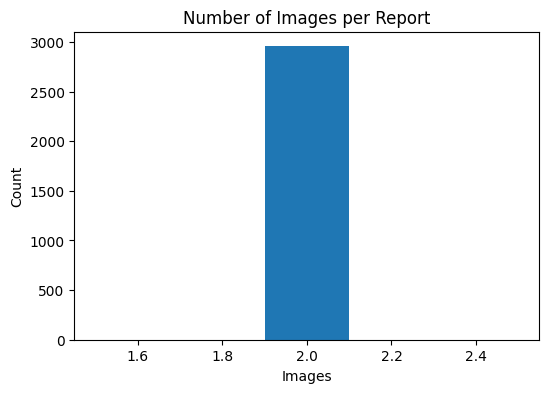

num_images
2    2955
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(6,4))

plt.hist(df["num_images"], bins=5)

plt.title("Number of Images per Report")
plt.xlabel("Images")
plt.ylabel("Count")

plt.show()

print(df["num_images"].value_counts())

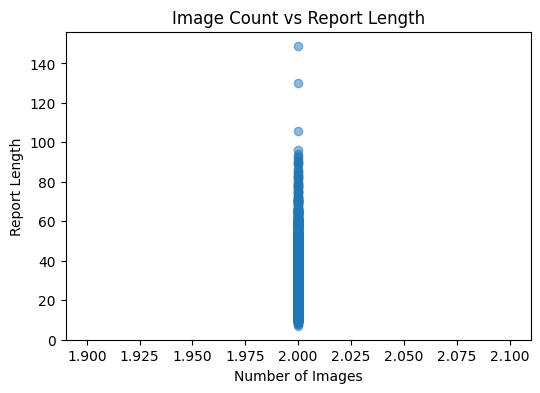

In [9]:
df["report_length"] = df["report"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))

plt.scatter(df["num_images"], df["report_length"], alpha=0.5)

plt.xlabel("Number of Images")
plt.ylabel("Report Length")

plt.title("Image Count vs Report Length")

plt.show()

REPORT:

The heart is normal in size. The mediastinum is unremarkable. There is XXXX biapical scarring. The lungs are otherwise clear.




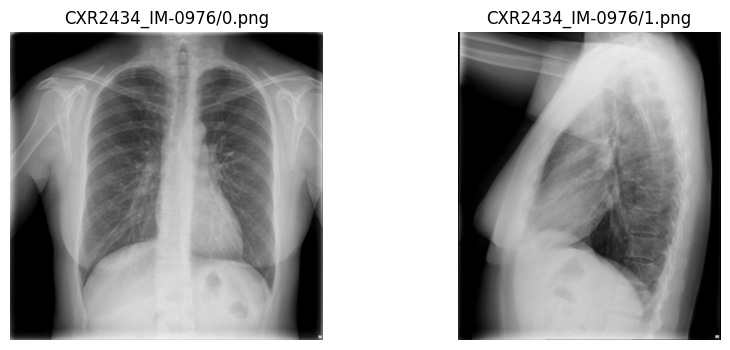

In [10]:
sample = random.choice(data["train"])

print("REPORT:\n")
print(sample["report"])
print("\n")

plt.figure(figsize=(10,4))

for i, img_path in enumerate(sample["image_path"]):
    
    full_path = os.path.join(image_root, img_path)
    
    img = cv2.imread(full_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(sample["image_path"]), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path)

plt.show()

REPORT:

2 images. Small centrally calcified granuloma within the lateral right lung base. Otherwise the lungs are clear. Heart size is normal. No evidence for pleural effusion or pneumothorax.




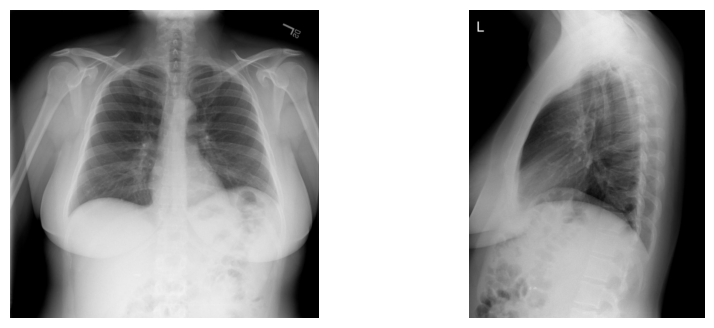

REPORT:

Heart size appears enlarged. Mediastinal contours are within normal limits. Lung volumes are low with central bronchovascular crowding and patchy basilar atelectasis.. Osseous structures are within normal limits for patient age.




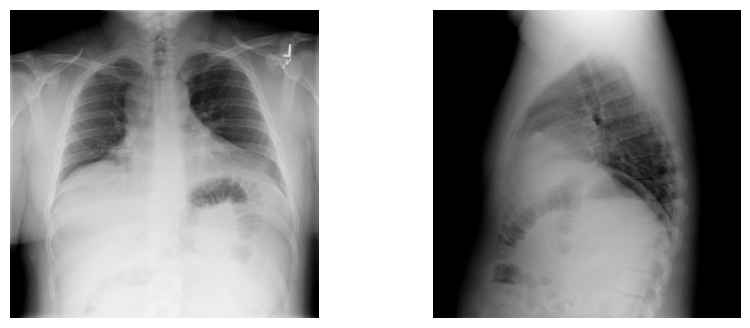

REPORT:

The heart and mediastinum are unremarkable. The lungs are clear without infiltrate. There is no effusion or pneumothorax. There is a mild levoscoliosis of the thoracic spine. There is mild widening of the right acromioclavicular joint which may be postsurgical or posttraumatic in XXXX.




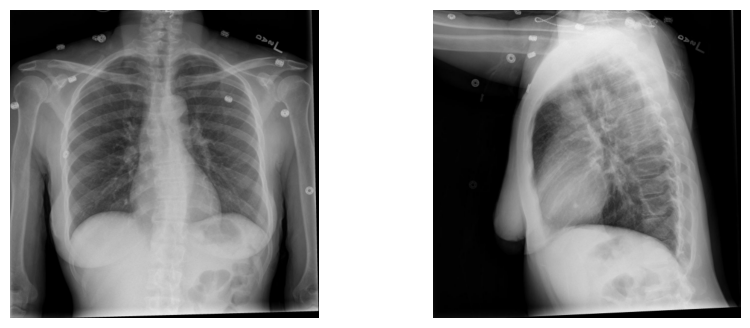

In [11]:
for _ in range(3):

    sample = random.choice(data["train"])
    
    print("REPORT:\n")
    print(sample["report"])
    print("\n")

    plt.figure(figsize=(10,4))

    for i, img_path in enumerate(sample["image_path"]):

        full_path = os.path.join(image_root, img_path)

        img = cv2.imread(full_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,len(sample["image_path"]),i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

In [12]:
missing = []

for split in ["train","val","test"]:

    for item in data[split]:

        for img in item["image_path"]:

            path = os.path.join(image_root,img)

            if not os.path.exists(path):

                missing.append(path)

print("Missing images:",len(missing))

Missing images: 0


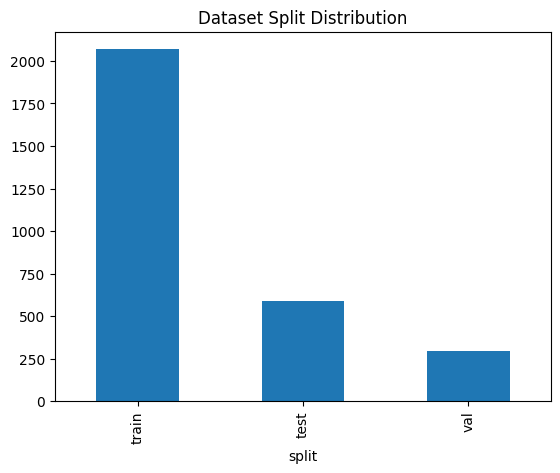

In [13]:
df["split"].value_counts().plot(kind="bar")

plt.title("Dataset Split Distribution")

plt.show()

In [14]:
image_counts = {"train":0,"val":0,"test":0}

for split in ["train","val","test"]:
    
    for item in data[split]:
        
        image_counts[split] += len(item["image_path"])

print(image_counts)

{'train': 4138, 'val': 592, 'test': 1180}
